In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util_multiset_copy import TripletModel, validate_model, train_model, get_base_rod
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
import equinox as eqx
import jax
import jax.numpy as jnp
from jaxtyping import Float


def inv_softplus(y: jax.Array) -> jax.Array:
    return jnp.log(jnp.expm1(y))


class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, out_features: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, out_features, key=key2)

        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jnp.ravel(x)
        x = jax.nn.tanh(self.layer1(x))
        x = self.layer2(x)
        return x   # shape (3,)


class Example(TripletModel):
    theta: jax.Array   # [raw_scale, raw_ratio, raw_beta]
    mlp: MLP
    rho: float
    beta_max: float
    corr_scale: float
    l_k: float   # <-- NEW

    def __init__(
        self,
        der_K: jax.Array,
        key: jax.Array,
        l_k: float,
        rho: float = 3.5,
        beta_max: float = 0.8,
        corr_scale: float = 1e-2,
    ):
        """
        der_K = [k_ss, k_sb, k_bb] (PHYSICAL values)

        l_k rescales stiffness:
            k_ss <- l_k * k_ss
            k_bb <- k_bb / l_k
        """
        der_K = jnp.ravel(der_K)
        if der_K.shape != (3,):
            raise ValueError(f"Expected der_K shape (3,), got {der_K.shape}")

        k_ss0, k_sb0, k_bb0 = der_K
        eps = 1e-6

        # ---- undo scaling to get base stiffness ----
        k_ss_base = k_ss0 / l_k
        k_bb_base = k_bb0 * l_k
        k_sb_base = k_sb0

        if k_ss_base <= 0 or k_bb_base <= 0:
            raise ValueError("Need positive base stiffness.")

        if k_ss_base * k_bb_base - 2.0 * k_sb_base**2 <= 0:
            raise ValueError("Base stiffness must be strictly PD.")

        # ---- convert to bounded parameterization ----
        s0 = k_bb_base
        r0 = k_ss_base / k_bb_base
        beta0 = jnp.sqrt(2.0) * k_sb_base / jnp.sqrt(k_ss_base * k_bb_base)

        log_r0 = jnp.log(r0)
        if jnp.abs(log_r0) >= rho:
            raise ValueError(
                f"Base ratio outside allowed range. "
                f"Try increasing rho or adjusting l_k."
            )

        if jnp.abs(beta0) >= beta_max:
            raise ValueError("Coupling too large for beta_max.")

        raw_scale0 = inv_softplus(s0 - eps)
        raw_ratio0 = jnp.arctanh(jnp.clip(log_r0 / rho, -0.999999, 0.999999))
        raw_beta0 = jnp.arctanh(jnp.clip(beta0 / beta_max, -0.999999, 0.999999))

        self.theta = jnp.array([raw_scale0, raw_ratio0, raw_beta0])
        self.mlp = MLP(in_features=5, hidden_size=10, out_features=3, key=key)
        self.rho = rho
        self.beta_max = beta_max
        self.corr_scale = corr_scale
        self.l_k = l_k

    def _bounded_parameters(self, del_strain):
        eps = 1e-6
        x = jnp.ravel(del_strain)

        dtheta = self.corr_scale * self.mlp(x)
        theta = self.theta + dtheta

        s = jax.nn.softplus(theta[0]) + eps
        log_r = self.rho * jnp.tanh(theta[1])
        r = jnp.exp(log_r)
        beta = self.beta_max * jnp.tanh(theta[2])

        return s, r, beta

    def get_K_entries(self, del_strain):
        # ---- base (well-conditioned) stiffness ----
        s, r, beta = self._bounded_parameters(del_strain)

        k_bb_base = s
        k_ss_base = s * r
        k_sb_base = beta * s * jnp.sqrt(r / 2.0)

        # ---- apply physical scaling ----
        k_ss = self.l_k * k_ss_base
        k_bb = k_bb_base / self.l_k
        k_sb = k_sb_base

        return jnp.array([k_ss, k_sb, k_bb])

    def get_K_matrix(self, del_strain):
        k_ss, k_sb, k_bb = self.get_K_entries(del_strain)
        return jnp.array([
            [k_ss, 0.0,  k_sb],
            [0.0,  k_ss, k_sb],
            [k_sb, k_sb, k_bb],
        ])

    def __call__(self, del_strain):
        del_strain = jnp.ravel(del_strain)

        e0 = del_strain[0]
        e1 = del_strain[1]
        eb = del_strain[3]

        k_ss, k_sb, k_bb = self.get_K_entries(del_strain)

        stretching_energy = 0.5 * k_ss * (e0**2 + e1**2)
        coupling_energy = k_sb * (e0 + e1) * eb
        bending_energy = 0.5 * k_bb * eb**2

        return stretching_energy + coupling_energy + bending_energy

In [3]:
from util import TestCase

# train_file = "output.npz"
# valid_file = "output_valid.npz"

train_file = "data/combined_output_train.npz"
valid_file = "data/combined_output_valid.npz"

init_K=jnp.array([1, 0.001, 0.5])
# validate_model(Example, der_K=init_K)

final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file=train_file, valid_file=valid_file, n_epochs=5000, lr=5e-2, init_K=init_K )
# final_model, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file="output_valid.npz", valid_file="output_valid.npz", n_epochs=100, lr=1e-2)

print( "initial K: ", init_K)
print( "learned K: ", final_model.get_K_entries(jnp.zeros(5)) )

xb_c:  [0.  0.  0.  0.  0.  0.5 0.  0. ]
xb_c:  [0.  0.  0.  0.  0.  0.5 0.  0. ]


/Users/radha/GitRepos/dismech-jax/examples/slinky/util_multiset_copy.py:50: UserWarning: data/combined_output_train.npz: expected xb_c to have shape (n_traj, n_b), got shape (2, 8). Using same xb_c for all trajectories.
  warnings.warn(
/Users/radha/GitRepos/dismech-jax/examples/slinky/util_multiset_copy.py:50: UserWarning: data/combined_output_valid.npz: expected xb_c to have shape (n_traj, n_b), got shape (2, 8). Using same xb_c for all trajectories.
  warnings.warn(


Step 0    | LR: 5.000e-02  | Train: 1.03421e-03  | Valid: 5.90587e-04  | K: [1.21298768 0.03140812 0.39948439]
Step 10   | LR: 5.000e-02  | Train: 1.70440e-04  | Valid: 2.06015e-04  | K: [0.56222551 0.12564713 0.05535294]
Step 20   | LR: 5.000e-02  | Train: 1.23711e-04  | Valid: 1.36217e-04  | K: [0.8605828  0.18022279 0.05216034]
Step 30   | LR: 5.000e-02  | Train: 7.84633e-05  | Valid: 7.10652e-05  | K: [0.87564432 0.15573053 0.04489816]
Step 40   | LR: 4.999e-02  | Train: 5.55405e-05  | Valid: 2.35880e-05  | K: [0.99008829 0.15390178 0.04531919]
Step 50   | LR: 4.999e-02  | Train: 4.31239e-05  | Valid: 1.45151e-05  | K: [1.18207748 0.16340663 0.04545154]
Step 60   | LR: 4.998e-02  | Train: 3.33313e-05  | Valid: 1.45501e-05  | K: [1.25030073 0.16351273 0.04078396]
Step 70   | LR: 4.998e-02  | Train: 2.68133e-05  | Valid: 1.22589e-05  | K: [1.38433011 0.17518023 0.03820871]
Step 80   | LR: 4.997e-02  | Train: 2.27408e-05  | Valid: 1.07151e-05  | K: [1.4695297  0.18109461 0.03550039]
S

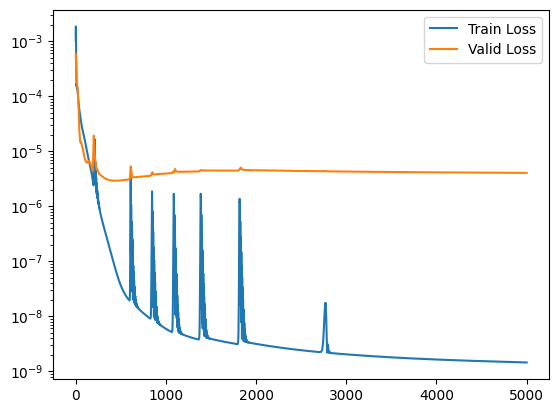

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
train = TestCase.from_npz(train_file)
valid = TestCase.from_npz(valid_file)
# train = TestCase.from_npz("output_valid.npz")
# valid = TestCase.from_npz("output_valid.npz")
print("Train:")
print("fixed idx:", train.bc.idx_b)
print("slope:", train.bc.xb_m)
print("intercept:", train.bc.xb_c)
print("Valid:")
print("fixed idx:", valid.bc.idx_b)
print("slope:", valid.bc.xb_m)
print("intercept:", valid.bc.xb_c)
lambdas = jnp.linspace(0.0, 1.0, valid.qs.shape[1])


Train:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[[ 0.   0.   0.   0.   0.  -0.4  0.   0. ]]

 [[ 0.   0.   0.   0.   0.   1.5  0.   0. ]]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]
Valid:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[[ 0.   0.   0.   0.   0.  -0.2  0.   0.1]]

 [[ 0.   0.   0.   0.   0.   0.5  0.  -0.1]]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]


In [6]:

print(valid.bc)
base, aux, _ = get_base_rod()
rods = base.with_bc(valid.bc)
print("Base rod: ", base)
print("Rods: ", rods)
pred = rods.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)
print(pred)
print(pred.shape)
print(valid.qs.shape)
print(train.qs.shape)
# animate(pred)

BatchedLinearBC(idx_b=i64[8](numpy), xb_m=f64[2,1,8](numpy), xb_c=f64[8](numpy))
Base rod:  Rod(
  triplets=Triplet(bar_strain=f64[1,5], l_k=f64[1,2]),
  mass=f64[11],
  q0=f64[11],
  E_ext=Gravity(F_ext=f64[11]),
  bc=AbstractBC()
)
Rods:  Rod(
  triplets=Triplet(bar_strain=f64[1,5], l_k=f64[1,2]),
  mass=f64[11],
  q0=f64[11],
  E_ext=Gravity(F_ext=f64[11]),
  bc=BatchedLinearBC(
    idx_b=i64[8](numpy), xb_m=f64[2,1,8](numpy), xb_c=f64[8](numpy)
  )
)
[[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    2.50002471e-01  3.10800066e-06 -1.70023280e-01  0.00000000e+00
    5.00000000e-01  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    2.41817562e-01  3.35586234e-06 -1.66358677e-01  0.00000000e+00
    4.80000000e-01  0.00000000e+00  1.00000000e-02]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    2.33797999e-01  4.07963117e-06 -1.62682653e-01  0.00000000e+00
    4.60000000e-01  0.00000000e+00 

In [7]:
# animate(valid.qs)

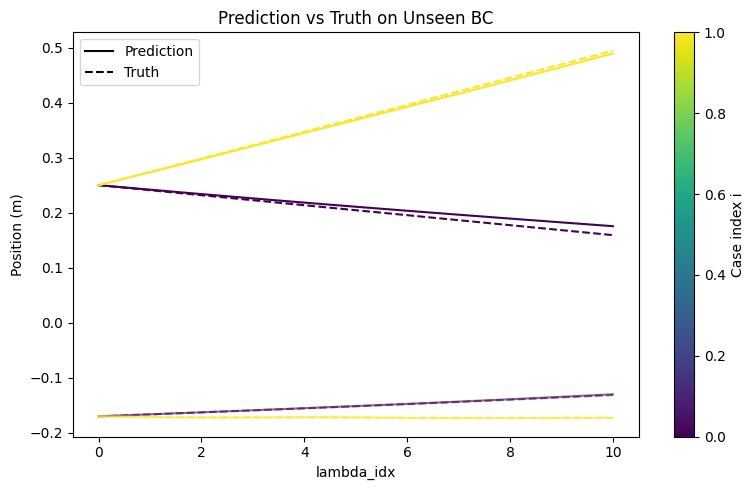

In [8]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import jax.numpy as jnp

n_cases = pred.shape[0]
colors = cm.viridis(jnp.linspace(0, 1, n_cases))

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n_cases):
    c = colors[i]

    # X
    ax.plot(pred[i, :, 4], color=c, linestyle='-')
    ax.plot(valid.qs[i, :, 4], color=c, linestyle='--')

    # Z
    ax.plot(pred[i, :, 6], color=c, linestyle='-', alpha=0.6)
    ax.plot(valid.qs[i, :, 6], color=c, linestyle='--', alpha=0.6)

pred_line = mlines.Line2D([], [], color='black', linestyle='-', label='Prediction')
truth_line = mlines.Line2D([], [], color='black', linestyle='--', label='Truth')
ax.legend(handles=[pred_line, truth_line])

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=n_cases - 1))
sm.set_array([])  # helps matplotlib know this is a valid mappable
fig.colorbar(sm, ax=ax, label='Case index i')

ax.set_title("Prediction vs Truth on Unseen BC")
ax.set_xlabel("lambda_idx")
ax.set_ylabel("Position (m)")
fig.tight_layout()
plt.show()

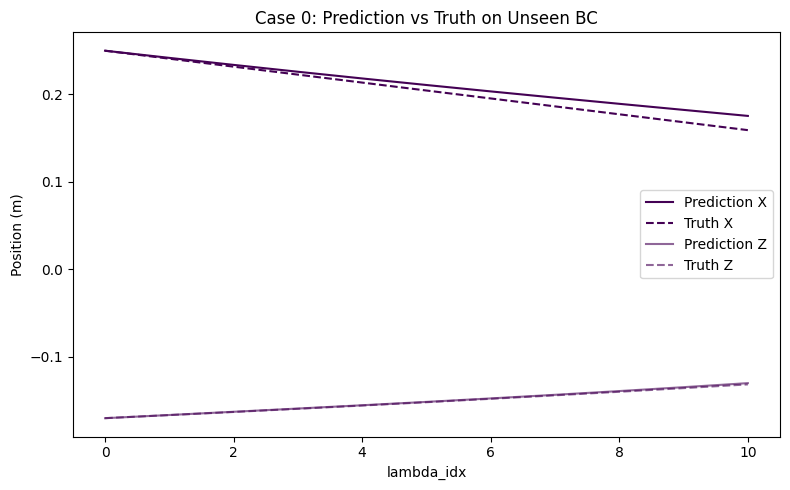

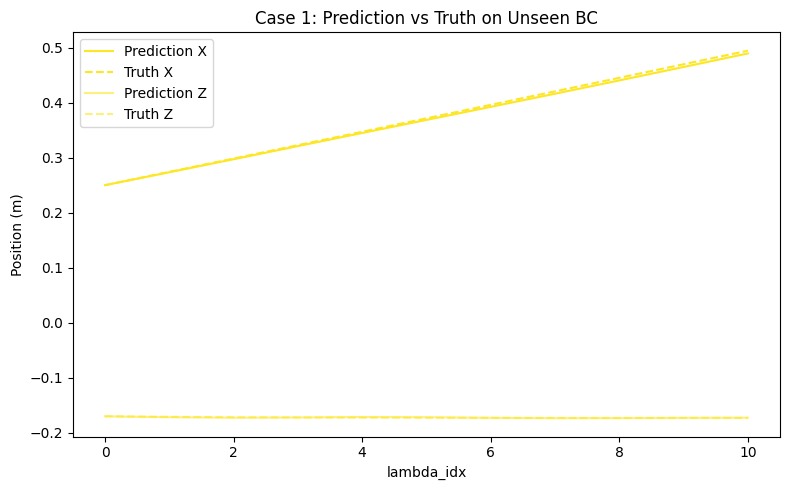

In [9]:
# create separate plots for all 5 cases for X and Z, with predicted and true on the same plot, and color by case index
for i in range(n_cases):
    c = colors[i]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(pred[i, :, 4], color=c, linestyle='-', label='Prediction X')
    ax.plot(valid.qs[i, :, 4], color=c, linestyle='--', label='Truth X')
    ax.plot(pred[i, :, 6], color=c, linestyle='-', alpha=0.6, label='Prediction Z')
    ax.plot(valid.qs[i, :, 6], color=c, linestyle='--', alpha=0.6, label='Truth Z')

    ax.set_title(f"Case {i}: Prediction vs Truth on Unseen BC")
    ax.set_xlabel("lambda_idx")
    ax.set_ylabel("Position (m)")
    ax.legend()
    fig.tight_layout()
    plt.show()

In [10]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   9.00157272e-02  6.23413092e-06 -1.87967656e-01  0.00000000e+00
   1.80000000e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   7.00164065e-02  5.87594802e-06 -1.89122811e-01  0.00000000e+00
   1.40000000e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   5.00171415e-02  5.53160840e-06 -1.90022059e-01  0.00000000e+00
   1.00000000e-01  0.00000000e+00  0.00000000e+00]]
final:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   8.50000004e-01  3.73486080e-07 -5.47967535e-02  0.00000000e+00
   1.70000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   9.24999861e-01 -3.54024268e-07 -3.84803710e-02  0.00000000e+00
   1.85000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.000

In [11]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.70012905e-01  7.72776659e-06 -1.80809173e-01  0.00000000e+00
   3.40000000e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.50013600e-01  7.33135081e-06 -1.82970911e-01  0.00000000e+00
   3.00000000e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.30014331e-01  6.96380666e-06 -1.84888700e-01  0.00000000e+00
   2.60000000e-01  0.00000000e+00  0.00000000e+00]]
final position of the middle node in the training data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   5.49999451e-01 -8.45845735e-06 -1.14145036e-01  0.00000000e+00
   1.10000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   6.24999659e-01 -6.23204214e-06 -9.96319008e-02  0.00000000e+00
   1.25000000e+00  

In [12]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.13578310e-01 -3.93045419e-05 -1.55548195e-01  0.00000000e+00
   4.20000000e-01  0.00000000e+00  4.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.04503547e-01 -5.37021584e-05 -1.51743620e-01  0.00000000e+00
   4.00000000e-01  0.00000000e+00  5.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.95437797e-01 -6.93358761e-05 -1.47852327e-01  0.00000000e+00
   3.80000000e-01  0.00000000e+00  6.00000000e-02]]
final position of the middle node in the validation data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   3.47015258e-01  1.46491388e-05 -1.72472247e-01  0.00000000e+00
   7.00000000e-01  0.00000000e+00 -4.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   3.71425859e-01  1.85378674e-05 -1.72679838e-01  0.00000000e+00
   7.50000000e-

In [13]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.18290684e-01  5.38945980e-06 -1.55220574e-01  0.00000000e+00
   4.20000000e-01  0.00000000e+00  4.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.10806436e-01  6.11647843e-06 -1.51371496e-01  0.00000000e+00
   4.00000000e-01  0.00000000e+00  5.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.03492843e-01  6.92800441e-06 -1.47400293e-01  0.00000000e+00
   3.80000000e-01  0.00000000e+00  6.00000000e-02]]
final position of the middle node in the prediction:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   3.44808594e-01 -1.78868115e-05 -1.71197322e-01  0.00000000e+00
   7.00000000e-01  0.00000000e+00 -4.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   3.68555129e-01 -1.85432679e-05 -1.71576749e-01  0.00000000e+00
   7.50000000e-01  0.0000